# Wave Field Animation: PEC Cylinders

Generates a wave field visualization for a slab of **PEC cylinders** ($\varepsilon = -1$).

PEC cylinders are perfect reflectors — waves bounce off completely. This makes them
much stronger scatterers than dielectric cylinders, resulting in lower transmission
for normal incidence but dramatic improvement with the optimal wavefront.

In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.smatrix import smatrix
from Scattering_Code.ky import ky

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
NUM_CYL    = 50
SEED       = 42
GRID_RES   = 200
PR_Y       = 7

nmax = int(np.floor(PERIOD / WAVELENGTH))  # PEC: propagating only
nm   = 2 * nmax + 1
n_eva = 0

## 1. Setup and Compute S-Matrix

In [3]:
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed = NUM_CYL / cyls_per_row + 2
thickness = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs = np.zeros((NUM_CYL, 2))
for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i, 0])**2 + (y - clocs[:i, 1])**2) > min_sep):
            clocs[i] = [x, y]
            break

sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, -1.0), np.full(NUM_CYL, MU)])  # PEC
crads  = np.full(NUM_CYL, RADIUS)

print(f"Computing S-matrix ({NUM_CYL} PEC cylinders)...")
t0 = time.time()
S, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
               nmax, thickness, sp, 'On')
print(f"Done in {time.time()-t0:.1f}s")

Computing S-matrix (50 PEC cylinders)...
  Computing T-Matrix...
  transall: 1225 pairs (1158 spectral, 67 spatial [vectorized])
  T-Matrix: 1.4s
  LU Decomposition...
  LU: 0.0s
  Computing S11 & S21...
  DEBUG: C_up.shape=(550, 27), nmax=13, GPU=False
  DEBUG: W2_up.shape=(27, 550)
  DEBUG: s21matrix.shape=(27, 27)
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 1.4s (0.0 min)
Done in 1.5s


## 2. Transmission Eigenvalue Distribution

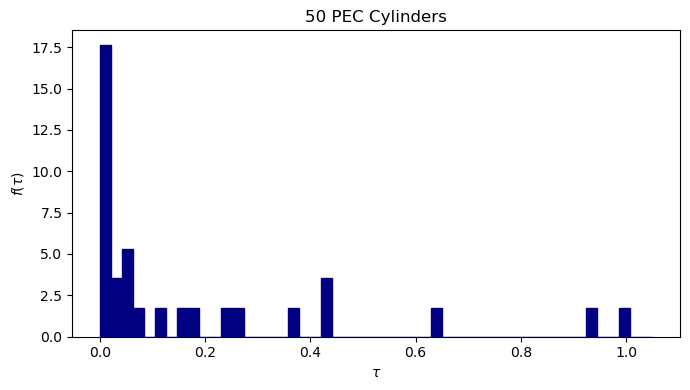

In [4]:
S11 = S[:nm, :nm]
S21 = S[nm:, :nm]
tau = svd(S21, compute_uv=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tau, bins=50, range=(0, 1.05), density=True, color='navy', edgecolor='navy')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$f(\tau)$')
ax.set_title(f'{NUM_CYL} PEC Cylinders')
plt.tight_layout()
plt.savefig('pec_tau_distribution.png', dpi=150)
plt.show()

## 3. Build Wave Fields

In [5]:
def build_field(S, nmax, thickness, mode='normal'):
    nm = 2 * nmax + 1
    S11 = S[:nm, :nm]
    S21 = S[nm:, :nm]
    
    if mode == 'opt_trans':
        U, s, Vh = svd(S11)
        v_in = Vh.conj().T[:, -1]
        tc = np.sum(np.abs(S21 @ v_in)**2)
        label = f'Optimal Wavefront — {tc*100:.1f}% transmitted'
    else:
        v_in = np.zeros(nm, dtype=complex)
        v_in[nmax] = 1.0
        tc = np.sum(np.abs(S21[:, nmax])**2)
        label = f'Normal Incidence — {tc*100:.1f}% transmitted'
    
    Input = v_in
    k = 2*np.pi / WAVELENGTH
    m_flo = np.arange(-nmax, nmax+1)
    kxs = 2*np.pi / PERIOD * m_flo
    kys = ky(k, kxs.astype(complex))
    
    P1 = np.diag(1.0 / np.sqrt(kys / k))
    Inc_c = P1 @ Input
    Ref_c = P1 @ (S11 @ Input)
    Tra_c = P1 @ (S21 @ Input)
    
    Nx = GRID_RES
    Ly = PR_Y * WAVELENGTH
    y_full = np.linspace(-Ly, thickness + Ly, GRID_RES * 2)
    x_phys = np.linspace(0, PERIOD, Nx)
    
    Field = np.zeros((Nx, len(y_full)), dtype=complex)
    for jy, y in enumerate(y_full):
        for ix in range(Nx):
            x = x_phys[ix]
            if y < 0:
                Field[ix, jy] = (
                    np.sum(Inc_c * np.exp(1j*(-kxs*x - kys*y))) +
                    np.sum(Ref_c * np.exp(1j*(-kxs*x + kys*y)))
                )
            elif y > thickness:
                Field[ix, jy] = np.sum(
                    Tra_c * np.exp(1j*(-kxs*x - kys*(y - thickness)))
                )
            else:
                alpha = y / thickness if thickness > 0 else 0
                fwd = Inc_c * (1-alpha) + Tra_c * alpha
                bwd = Ref_c * (1-alpha)
                Field[ix, jy] = (
                    np.sum(fwd * np.exp(1j*(-kxs*x - kys*y))) +
                    np.sum(bwd * np.exp(1j*(-kxs*x + kys*y)))
                )
    
    return Field, x_phys / WAVELENGTH, y_full / WAVELENGTH, label

print("Building normal incidence field...")
F_norm, x_grid, y_grid, label_norm = build_field(S, nmax, thickness, 'normal')
print(f"  {label_norm}")

print("Building optimal wavefront field...")
F_opt, _, _, label_opt = build_field(S, nmax, thickness, 'opt_trans')
print(f"  {label_opt}")

Building normal incidence field...
  Normal Incidence — 12.2% transmitted
Building optimal wavefront field...
  Optimal Wavefront — 98.9% transmitted


## 4. Plot Wave Fields

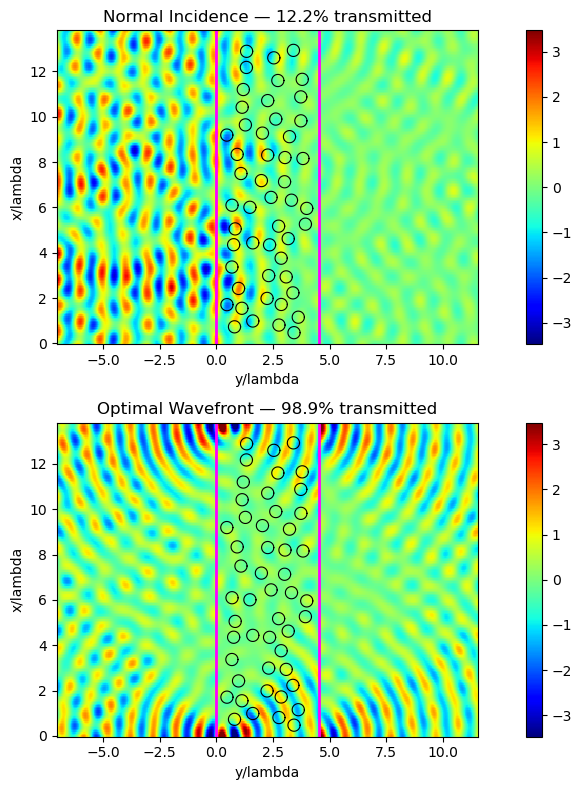

In [6]:
vmax = max(np.max(np.abs(np.real(F_norm))), np.max(np.abs(np.real(F_opt)))) * 0.7

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, F, label in zip(axes, [F_norm, F_opt], [label_norm, label_opt]):
    im = ax.pcolormesh(y_grid, x_grid, np.real(F), cmap='jet', vmin=-vmax, vmax=vmax)
    ax.axvline(0, color='magenta', lw=2)
    ax.axvline(thickness / WAVELENGTH, color='magenta', lw=2)
    # Draw cylinder outlines
    theta = np.linspace(0, 2*np.pi, 40)
    for i in range(NUM_CYL):
        cx = clocs[i,1] / WAVELENGTH
        cy = clocs[i,0] / WAVELENGTH
        r_lam = RADIUS / WAVELENGTH
        ax.plot(cx + r_lam*np.cos(theta), cy + r_lam*np.sin(theta), 'k-', lw=0.8)
    ax.set_xlabel('y/lambda')
    ax.set_ylabel('x/lambda')
    ax.set_title(label)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('pec_wave_field.png', dpi=150)
plt.show()

## 5. Wave Animation

Animate the wave field by sweeping phase over one full cycle:
`Re(F · exp(-iφ))` for φ ∈ [0, 2π]. Both modes shown simultaneously.

In [ ]:
import matplotlib.animation as animation

N_FRAMES = 40
phases = np.linspace(0, 2*np.pi, N_FRAMES, endpoint=False)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

vmax_anim = max(np.max(np.abs(F_norm)), np.max(np.abs(F_opt))) * 0.7

theta = np.linspace(0, 2*np.pi, 40)

ims = []
for ax, F, label in zip(axes, [F_norm, F_opt], [label_norm, label_opt]):
    im = ax.pcolormesh(y_grid, x_grid, np.real(F), cmap='jet',
                       vmin=-vmax_anim, vmax=vmax_anim, shading='auto')
    ax.axvline(0, color='magenta', lw=2)
    ax.axvline(thickness / WAVELENGTH, color='magenta', lw=2)
    for i in range(NUM_CYL):
        cx = clocs[i, 1] / WAVELENGTH
        cy = clocs[i, 0] / WAVELENGTH
        r_lam = RADIUS / WAVELENGTH
        ax.plot(cx + r_lam * np.cos(theta), cy + r_lam * np.sin(theta), 'k-', lw=0.5)
    ax.set_xlabel(r'y/λ')
    ax.set_ylabel(r'x/λ')
    ax.set_title(label)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)
    ims.append(im)

plt.tight_layout()

def update(frame):
    phi = phases[frame]
    for im, F in zip(ims, [F_norm, F_opt]):
        im.set_array(np.real(F * np.exp(-1j * phi)))
    return ims

anim = animation.FuncAnimation(fig, update, frames=N_FRAMES, interval=80, blit=True)

print("Saving pec_wave_animation.mp4 ...")
anim.save('pec_wave_animation.mp4', writer='ffmpeg', fps=15, dpi=120)
print("Saved: pec_wave_animation.mp4")
plt.close(fig)
